<a href="https://colab.research.google.com/github/aniget/SoftUni-AI-Integrations-for-developers/blob/main/Images_Audio_Video/Image_Generation_from_Image_with_HF_model_Stable_DIfusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
# -q flag suppresses verbose output, keeping the notebook clean
# diffusers  : HuggingFace library for diffusion models
# transformers: tokenizers, text encoders (CLIP etc.)
# accelerate : enables efficient model loading across devices
# safetensors: safer/faster alternative to pickle-based weights
# torch      : PyTorch — the deep learning backbone
!pip install -q diffusers transformers accelerate safetensors torch

In [1]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import io
import torch
from PIL import Image                                    # image loading & manipulation
from IPython.display import display                     # render images inline in Colab
from google.colab import files, userdata               # Colab file upload + secrets
from diffusers import StableDiffusionImg2ImgPipeline   # img2img pipeline from HuggingFace

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
# ============================================================
# CELL 3 — Configuration (centralise all tuneable parameters)
# ============================================================
# 📌 BEST PRACTICE: keep all hyperparameters in one place

CONFIG = {
    "model_id"        : "runwayml/stable-diffusion-v1-5",
    "prompt"          : "a fantasy apple orchard at dawn, ethereal morning light, photorealistic",
    "negative_prompt" : "cartoon, painting, sketch, lowres, blurry, watermark",
    "strength"        : 0.70,   # 0.0 = identical to input, 1.0 = ignore input completely
    "guidance_scale"  : 7.5,    # how strictly the model follows the prompt (7–12 is typical)
    "num_steps"       : 30,     # more steps → better quality, slower generation
    "output_file"     : "output.png",
}

In [4]:
# ============================================================
# CELL 4 — Load the pipeline
# ============================================================
# Retrieve the HuggingFace token stored in Colab Secrets
# (Runtime → Manage secrets → add key "HuggingFace_API_KEY")
hf_token = userdata.get("HuggingFace_API_KEY")

# torch.float16 (half precision) halves VRAM usage vs float32
# variant="fp16" fetches the pre-converted fp16 weight files
# use_safetensors=True avoids loading untrusted pickle files
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    CONFIG["model_id"],
    torch_dtype=torch.float16,
    variant="fp16",
    token=hf_token,
    use_safetensors=True,
).to("cuda")  # move entire pipeline to GPU

# VAE slicing processes the image in slices → reduces VRAM spike
# at the cost of a small speed penalty — recommended on free Colab
pipe.enable_vae_slicing()

print("✅ Pipeline loaded successfully")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Pipeline loaded successfully


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


📂 Upload an image to transform:


Saving apple_orchard_at_sunrise.png to apple_orchard_at_sunrise.png
✅ Image loaded and resized: 512×512 → 512×512


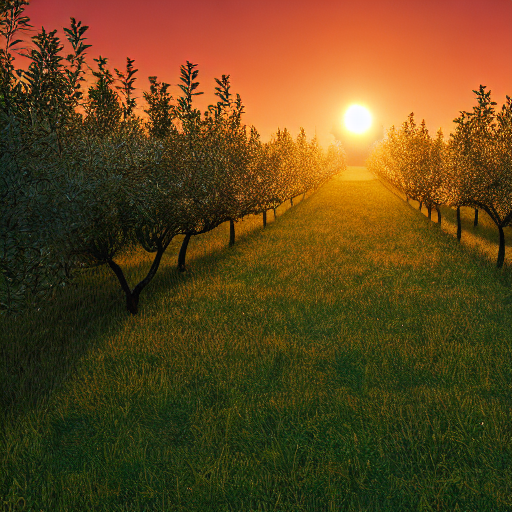

In [5]:
# ============================================================
# CELL 5 — Upload & pre-process image
# ============================================================
print("📂 Upload an image to transform:")
uploaded = files.upload()

# files.upload() returns {filename: bytes}; we grab the first file
file_bytes = next(iter(uploaded.values()))

# Always convert to RGB — uploaded files may be RGBA (PNG with
# transparency) or L (greyscale), which SD does not accept
input_image = Image.open(io.BytesIO(file_bytes)).convert("RGB")

# ── Resize to a multiple of 8 ────────────────────────────────
# Stable Diffusion's VAE uses 8× downsampling; dimensions that
# are not multiples of 8 cause shape mismatches inside the model
w, h = input_image.size
new_w = (w // 8) * 8
new_h = (h // 8) * 8

# Image.LANCZOS is the highest-quality resampling filter in Pillow
input_image = input_image.resize((new_w, new_h), Image.LANCZOS)

print(f"✅ Image loaded and resized: {w}×{h} → {new_w}×{new_h}")
display(input_image)   # preview the input before generation

In [6]:
# ============================================================
# CELL 6 — Generate the transformed image
# ============================================================
# torch.autocast runs the forward pass in mixed precision,
# speeding up inference while keeping numerical stability
with torch.autocast("cuda"):
    result = pipe(
        prompt          = CONFIG["prompt"],
        image           = input_image,      # ✅ correct kwarg is "image", not "init_image"
        strength        = CONFIG["strength"],
        guidance_scale  = CONFIG["guidance_scale"],
        num_inference_steps = CONFIG["num_steps"],
        negative_prompt = CONFIG["negative_prompt"],
    )

output_image = result.images[0]



  0%|          | 0/21 [00:00<?, ?it/s]

✅ Saved → output.png


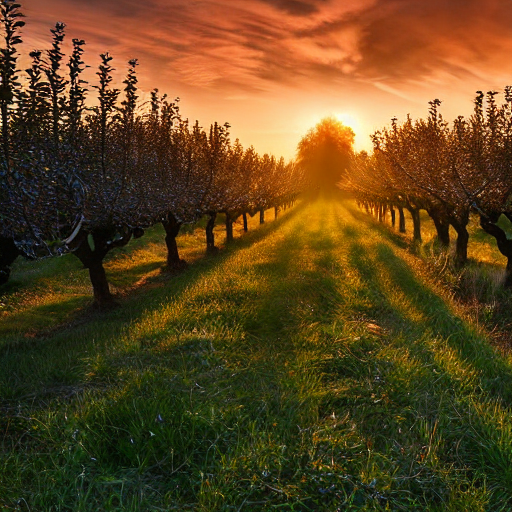

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# ============================================================
# CELL 7 — Save & display result
# ============================================================
output_image.save(CONFIG["output_file"])
print(f"✅ Saved → {CONFIG['output_file']}")
display(output_image)

# Optional: download directly to your machine
files.download(CONFIG["output_file"])